In [8]:
import pandas as pd

df = pd.read_csv("cs4900responses.csv")

# clean up common junk cols + whitespace
df = df.loc[:, ~df.columns.str.contains(r"^Unnamed")]
df.columns = df.columns.str.strip().str.replace(r"\s+", " ", regex=True)

df.head()

,Timestamp,Score,Name,Does Category F or Category K have the higher value?,Does Category B or F have the higher value?,How much bigger is Category B compared to Category A?,How much bigger is Category T compared to Category S?,Does Category D or Category G have the higher value?,How much bigger is Category G compared to Category D?,Does Category F or Category K have the higher value?.1,How much bigger is Category D compared to Category A?,Does Category G or Category L have the higher value?,How much bigger is Category F compared to Category C?,Does Category E or Category P have the higher value?,How much bigger is Category D compared to Category G?
0,2/26/2026 18:01:49,10 / 12,Kent Alvarez,Category K,Category B,2 units bigger,8 units bigger,Category G,5 units bigger,Category K,8 units,Category L,9 units bigger,Category P,3 units bigger
1,2/26/2026 18:18:27,7 / 12,Anonymous,Category K,Category B,5 units bigger,10 units bigger,Category G,3 units bigger,Category K,10 units,Category L,9 units bigger,Category E,3 units bigger
2,2/26/2026 18:21:51,9 / 12,CB,Category K,Category B,2 units bigger,8 units bigger,Category G,10 units bigger,Category K,5 units,Category L,9 units bigger,Category P,5 units bigger
3,2/26/2026 18:31:18,9 / 12,Na,Category K,Category B,1 unit bigger,8 units bigger,Category G,5 units bigger,Category K,10 units,Category L,9 units bigger,Category E,3 units bigger
4,2/26/2026 18:40:37,10 / 12,Miranda,Category K,Category B,2 units bigger,8 units bigger,Category G,5 units bigger,Category K,5 units,Category L,9 units bigger,Category P,3 units bigger


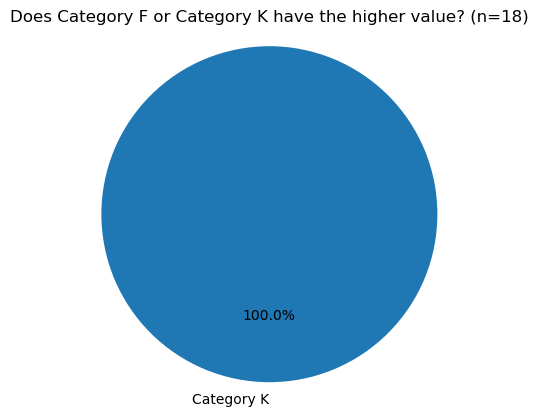

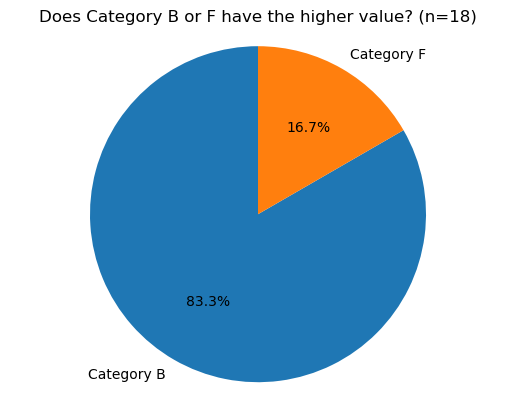

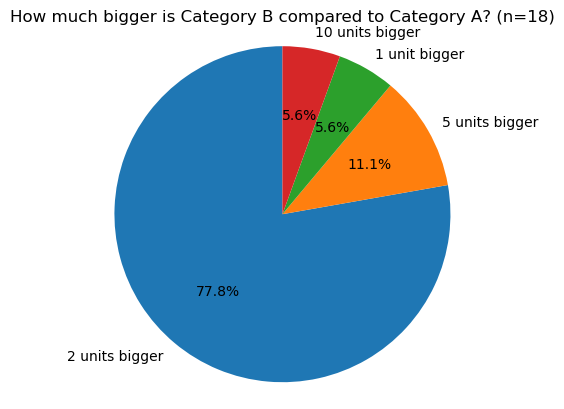

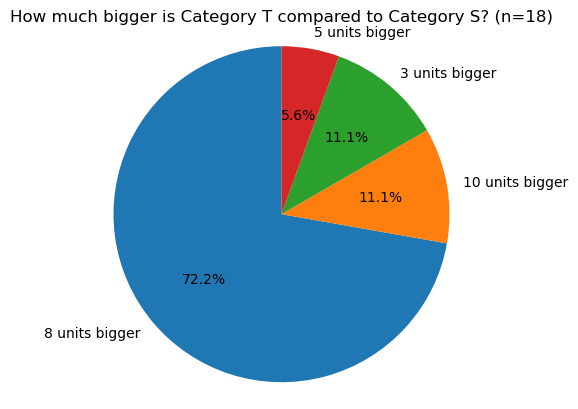

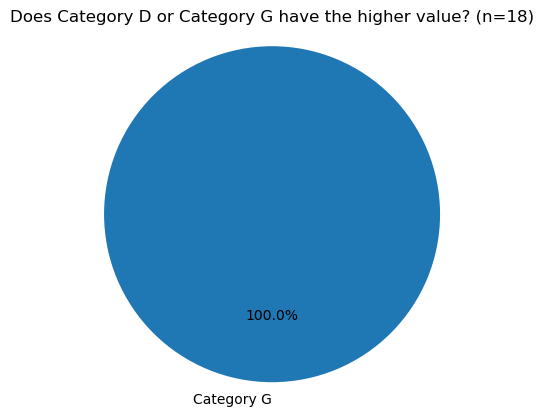

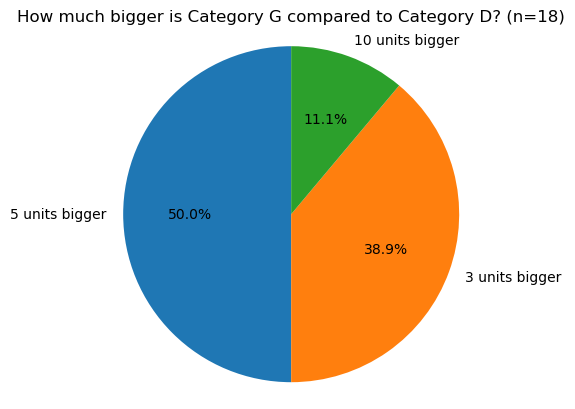

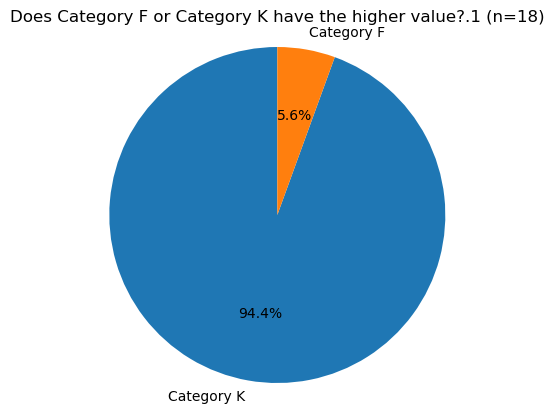

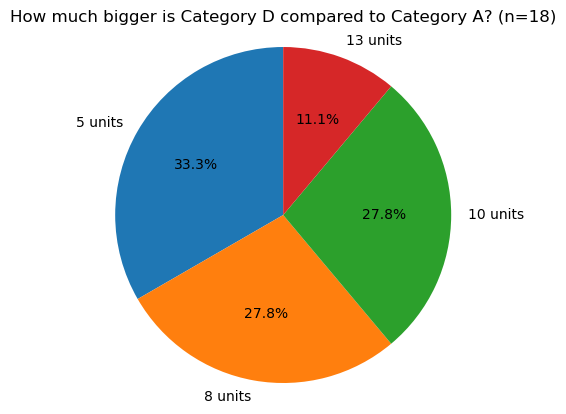

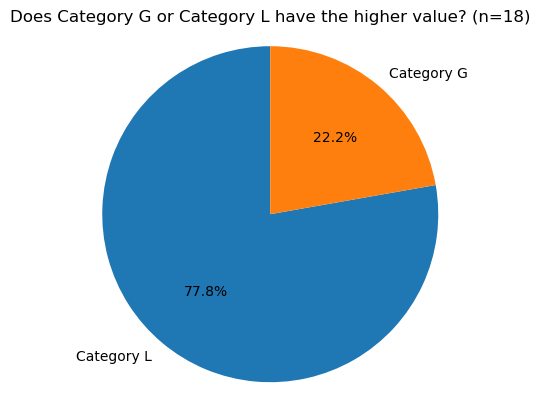

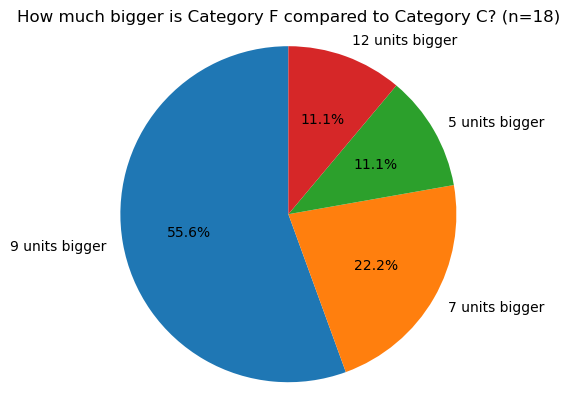

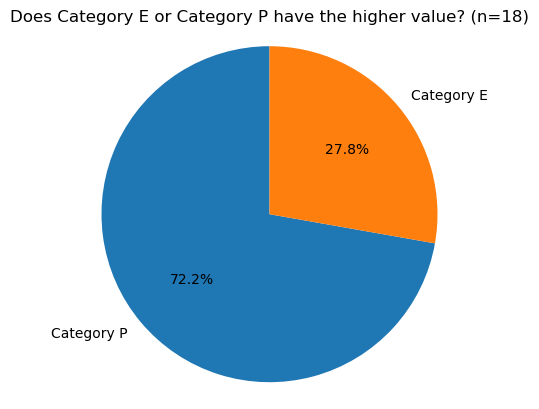

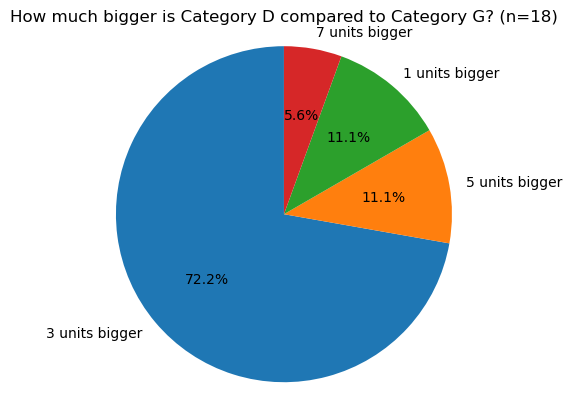

In [10]:
import matplotlib.pyplot as plt

# columns 4th to the end (0-based index 3)
for col in df.columns[3:]:
    s = df[col].astype("object")

    # treat blanks/NaN as "Missing"
    s = s.where(~s.isna(), "Missing")
    s = s.apply(lambda x: x.strip() if isinstance(x, str) else x)
    s = s.replace("", "Missing")

    counts = s.value_counts(dropna=False)

    plt.figure()
    plt.pie(
        counts.values,
        labels=counts.index.astype(str),
        autopct=lambda p: f"{p:.1f}%" if p >= 3 else "",  # hide tiny % labels
        startangle=90
    )
    plt.title(f"{col} (n={len(s)})")
    plt.axis("equal")
    plt.show()

In [12]:
# most-popular answer (mode) for each column 4th -> end
cols = df.columns[3:]

correct_answers = []
for col in cols:
    s = df[col].astype("object")

    # normalize missing/blank
    s = s.where(~s.isna(), "Missing")
    s = s.apply(lambda x: x.strip() if isinstance(x, str) else x)
    s = s.replace("", "Missing")

    # most frequent value
    correct_answers.append(s.value_counts().idxmax())

correct_answers

['Category K',
 'Category B',
 '2 units bigger',
 '8 units bigger',
 'Category G',
 '5 units bigger',
 'Category K',
 '5 units',
 'Category L',
 '9 units bigger',
 'Category P',
 '3 units bigger']

In [14]:
correct_answers[7] = '10 units'
correct_answers

['Category K',
 'Category B',
 '2 units bigger',
 '8 units bigger',
 'Category G',
 '5 units bigger',
 'Category K',
 '10 units',
 'Category L',
 '9 units bigger',
 'Category P',
 '3 units bigger']

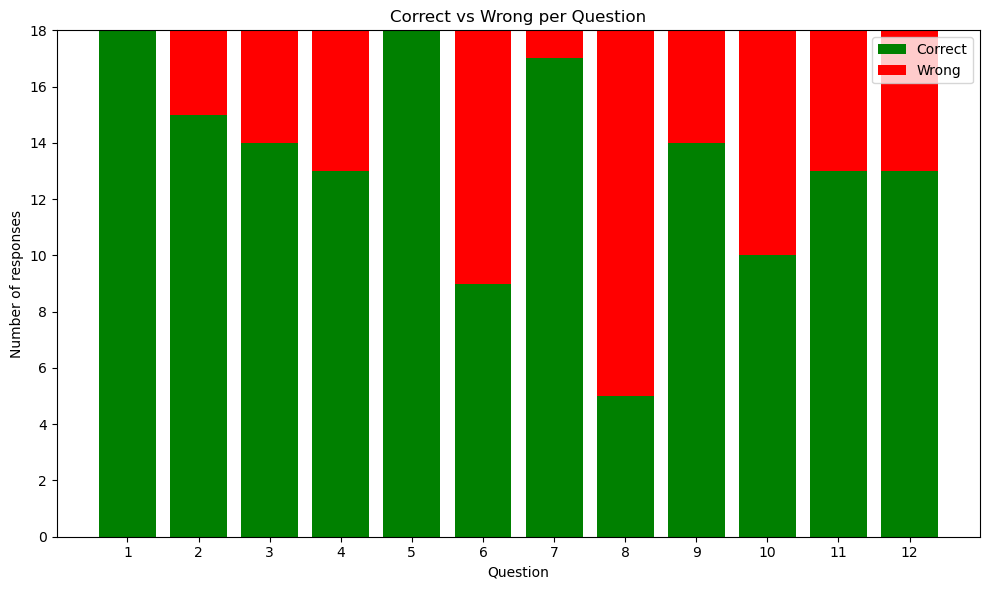

In [41]:
import numpy as np

cols = df.columns[3:]
q_nums = np.arange(1, len(cols) + 1)   # 1..N for ticks

correct_counts, wrong_counts = [], []

for col, correct in zip(cols, correct_answers):
    s = df[col].astype("object")
    s = s.where(~s.isna(), "Missing")
    s = s.apply(lambda x: x.strip() if isinstance(x, str) else x).replace("", "Missing")

    correct_n = (s == correct).sum()
    wrong_n   = (s != correct).sum()

    correct_counts.append(correct_n)
    wrong_counts.append(wrong_n)

x = np.arange(len(cols))

plt.figure(figsize=(max(10, len(cols) * 0.6), 6))
plt.bar(x, correct_counts, color="green", label="Correct")
plt.bar(x, wrong_counts, bottom=correct_counts, color="red", label="Wrong")

plt.xticks(x, q_nums)                 # just numbers per tick
plt.xlabel("Question")                # x-axis title
plt.ylabel("Number of responses")
plt.title("Correct vs Wrong per Question")
plt.ylim(0, 18)
plt.legend()
plt.tight_layout()

plt.savefig("allquestiondistribution.png", dpi=300, bbox_inches="tight")
plt.show()

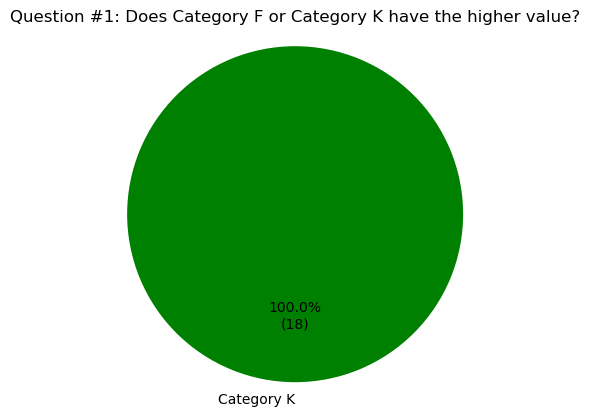

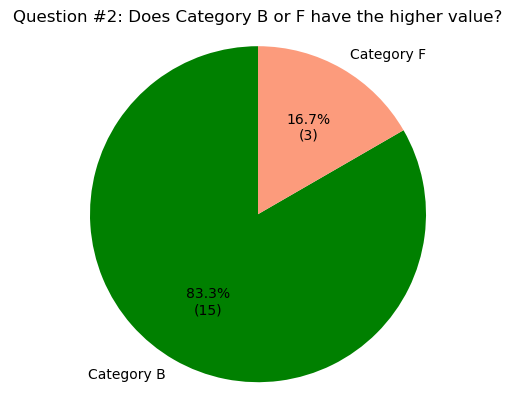

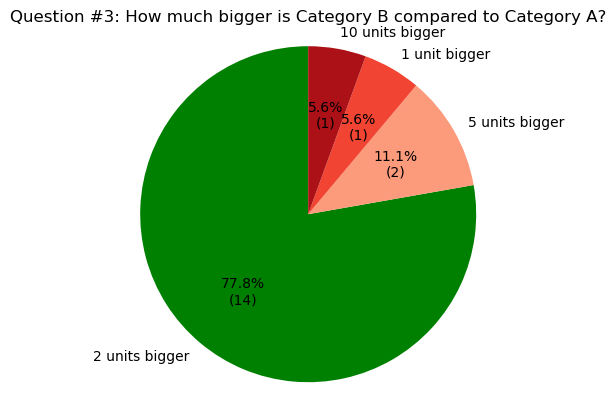

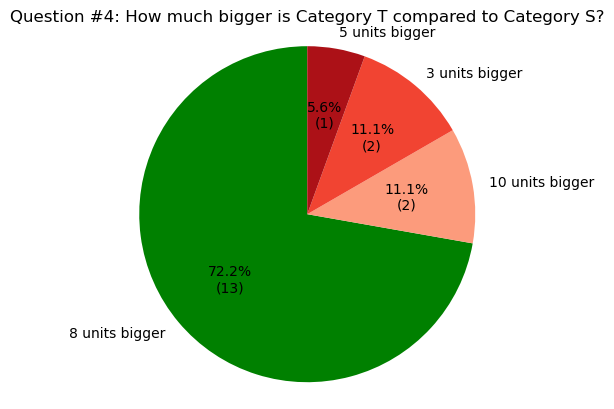

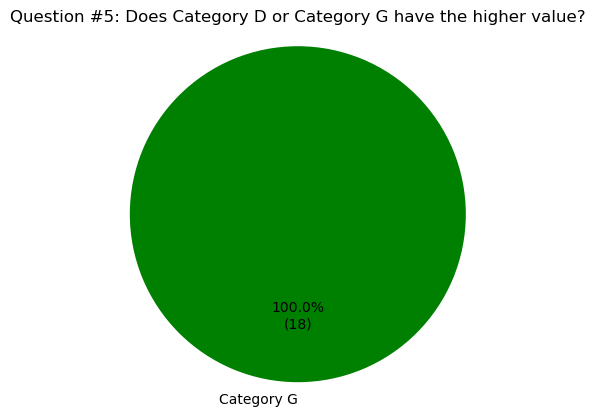

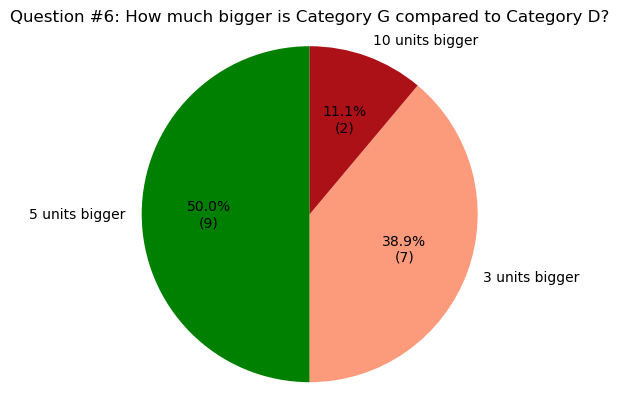

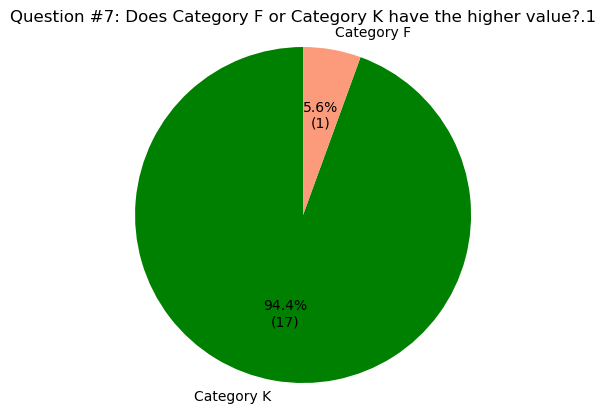

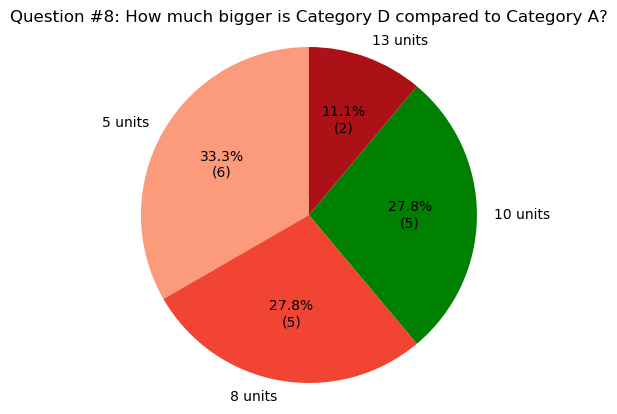

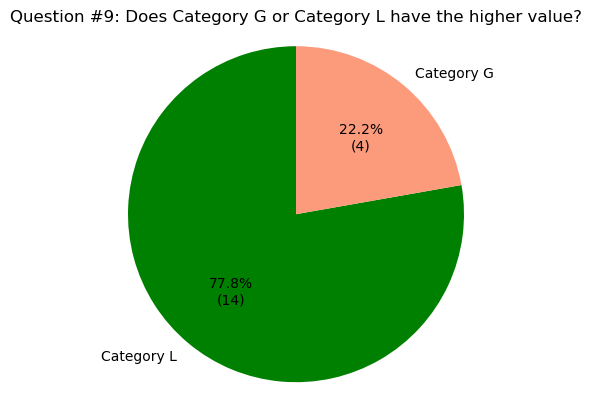

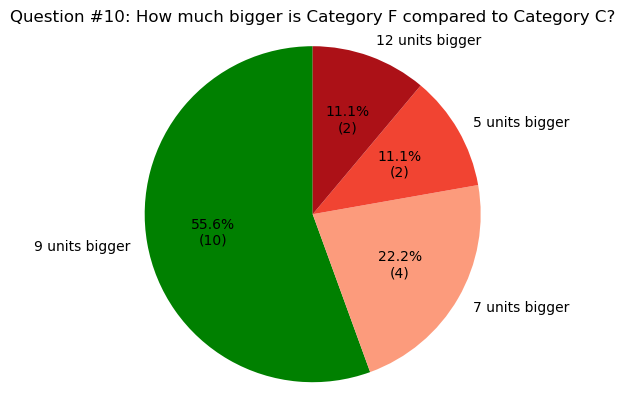

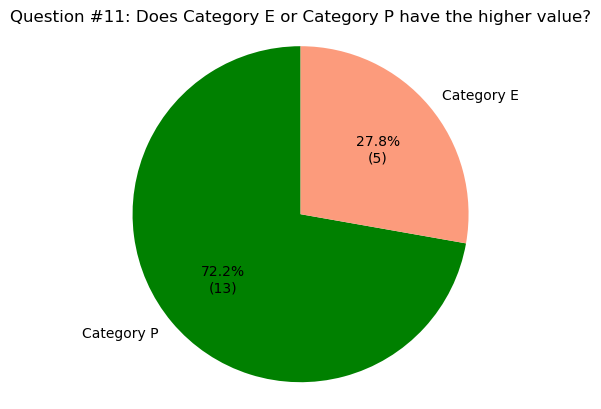

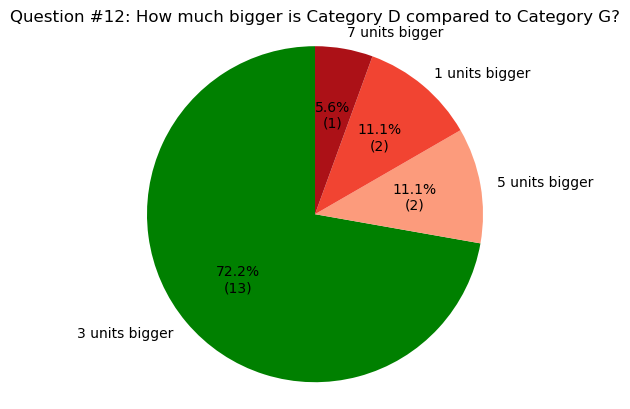

In [49]:
for i, (col, correct) in enumerate(zip(df.columns[3:], correct_answers), start=1):
    s = df[col].astype("object")
    s = s.where(~s.isna(), "Missing")
    s = s.apply(lambda x: x.strip() if isinstance(x, str) else x).replace("", "Missing")

    counts = s.value_counts(dropna=False)
    labels = counts.index.astype(str).tolist()
    sizes  = counts.values.tolist()
    total  = sum(sizes)

    # --- colors: correct = green, wrong = varying reds ---
    wrong_idx = [j for j, lab in enumerate(labels) if lab != str(correct)]
    n_wrong = len(wrong_idx)

    # generate red shades for wrong answers (lighter -> darker)
    reds = plt.cm.Reds(np.linspace(0.35, 0.85, max(n_wrong, 1)))
    colors = []
    wrong_k = 0
    for lab in labels:
        if lab == str(correct):
            colors.append("green")
        else:
            colors.append(reds[wrong_k])
            wrong_k += 1

    # autopct that prints both % and count reliably
    def autopct_factory(values):
        vals = values.copy()
        def _autopct(pct):
            v = vals.pop(0)
            return f"{pct:.1f}%\n({v})" if pct > 0 else ""
        return _autopct

    plt.figure()
    plt.pie(
        sizes,
        labels=labels,
        colors=colors,
        autopct=autopct_factory(sizes),
        startangle=90
    )
    plt.title(f"Question #{i}: {col}")
    plt.axis("equal")
    plt.savefig(f"question{i}results.png", dpi=300, bbox_inches="tight")
    plt.show()

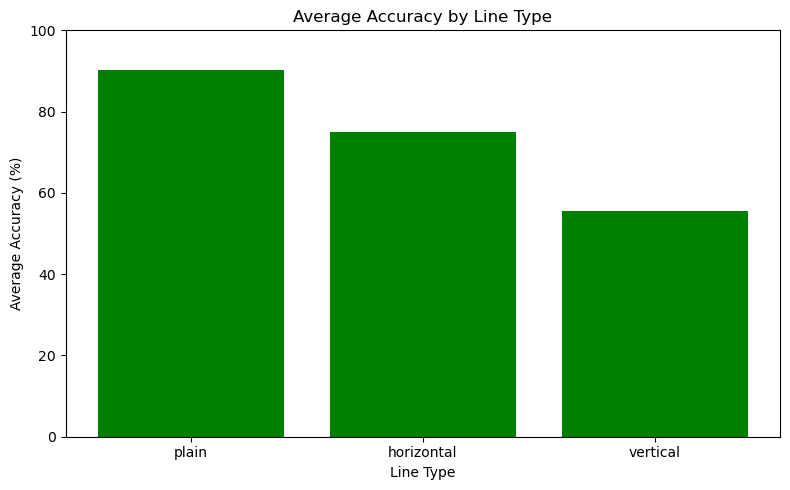

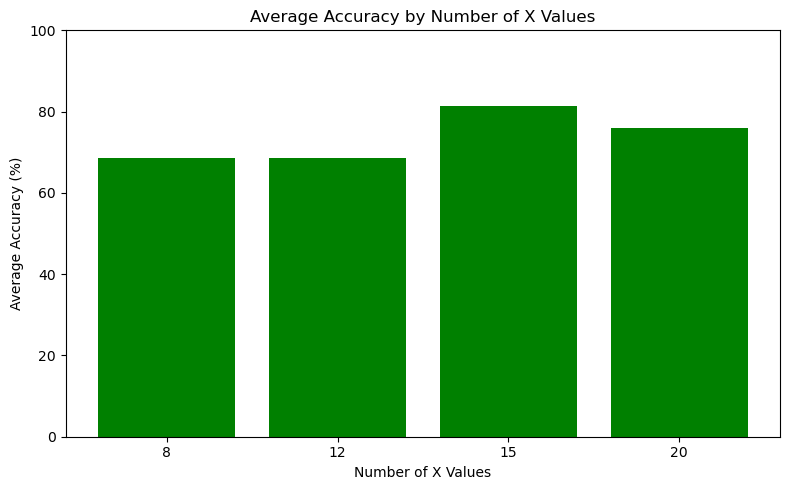

In [53]:
# --- assumes df is already loaded and cleaned ---
q_cols = df.columns[3:][:12]

# if correct_answers isn't defined yet, uncomment this to compute it as the mode per question
# correct_answers = []
# for col in q_cols:
#     s = df[col].astype("object").where(~df[col].isna(), "Missing")
#     s = s.apply(lambda x: x.strip() if isinstance(x, str) else x).replace("", "Missing")
#     correct_answers.append(s.value_counts().idxmax())

# per-question accuracy
q_acc = []
for col, correct in zip(q_cols, correct_answers[:12]):
    s = df[col].astype("object").where(~df[col].isna(), "Missing")
    s = s.apply(lambda x: x.strip() if isinstance(x, str) else x).replace("", "Missing")
    q_acc.append((s == correct).mean())

# -------------------------
# VISUAL 1: avg accuracy by line_type (green)
# -------------------------
line_types = [
    "plain", "plain", "plain", "horizontal", "plain", "vertical",
    "horizontal", "vertical", "horizontal", "horizontal", "vertical", "vertical"
]

summary = pd.DataFrame({
    "question": np.arange(1, 13),
    "line_type": line_types,
    "accuracy": q_acc
})

acc_by_line = (summary.groupby("line_type")["accuracy"].mean() * 100).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(acc_by_line.index, acc_by_line.values, color="green")
plt.ylabel("Average Accuracy (%)")
plt.xlabel("Line Type")
plt.title("Average Accuracy by Line Type")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

# -------------------------
# VISUAL 2: avg accuracy by number of x values (green)
# -------------------------
x_values = [12, 20, 15, 20, 8, 8, 15, 12, 12, 8, 20, 15]  # Q1..Q12

summary2 = pd.DataFrame({
    "question": np.arange(1, 13),
    "x_values": x_values,
    "accuracy": q_acc
})

acc_by_x = (summary2.groupby("x_values")["accuracy"].mean() * 100).sort_index()

plt.figure(figsize=(8, 5))
plt.bar(acc_by_x.index.astype(str), acc_by_x.values, color="green")
plt.ylabel("Average Accuracy (%)")
plt.xlabel("Number of X Values")
plt.title("Average Accuracy by Number of X Values")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

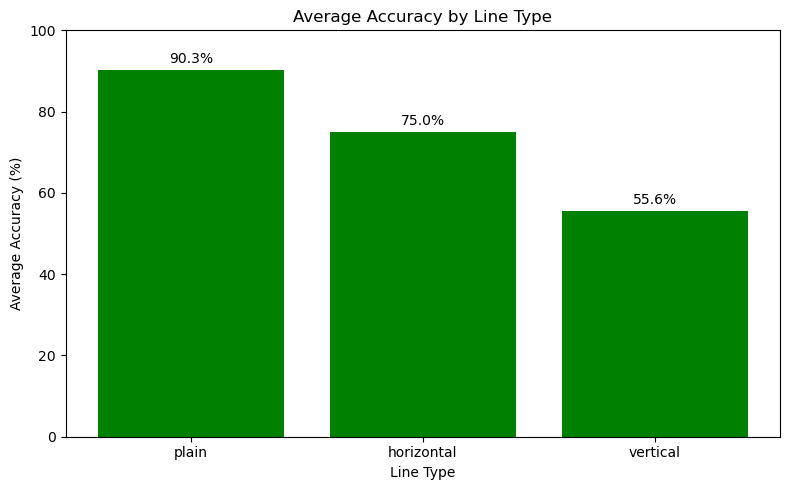

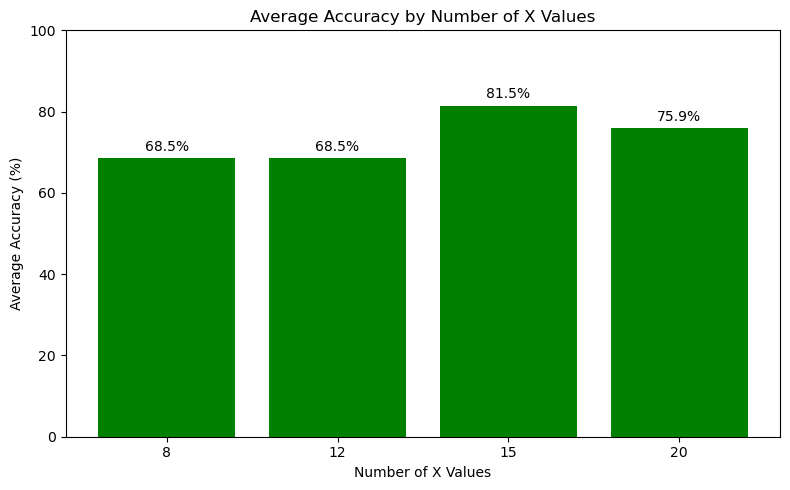

In [57]:
def add_bar_labels(ax, fmt="{:.1f}%"):
    for p in ax.patches:
        h = p.get_height()
        ax.annotate(fmt.format(h),
                    (p.get_x() + p.get_width()/2, h),
                    ha="center", va="bottom",
                    xytext=(0, 3), textcoords="offset points")

# --- VISUAL 1 (save) ---
plt.figure(figsize=(8, 5))
ax = plt.gca()
ax.bar(acc_by_line.index, acc_by_line.values, color="green")
ax.set_ylabel("Average Accuracy (%)")
ax.set_xlabel("Line Type")
ax.set_title("Average Accuracy by Line Type")
ax.set_ylim(0, 100)
add_bar_labels(ax)
plt.tight_layout()
plt.savefig("avg_accuracy_by_line_type.png", dpi=300, bbox_inches="tight")
plt.show()

# --- VISUAL 2 (save) ---
plt.figure(figsize=(8, 5))
ax = plt.gca()
ax.bar(acc_by_x.index.astype(str), acc_by_x.values, color="green")
ax.set_ylabel("Average Accuracy (%)")
ax.set_xlabel("Number of X Values")
ax.set_title("Average Accuracy by Number of X Values")
ax.set_ylim(0, 100)
add_bar_labels(ax)
plt.tight_layout()
plt.savefig("avg_accuracy_by_x_values.png", dpi=300, bbox_inches="tight")
plt.show()